# Datathon Fase 5 — Case Passos Mágicos
## Notebook 2 · Modelo preditivo de risco de defasagem (Pergunta 9)

*Quais padrões nos indicadores permitem identificar alunos em risco antes da queda de desempenho ou do aumento da defasagem? Construa um modelo que mostre a probabilidade do aluno entrar em risco de defasagem.*

### Definição do problema
- **Unidade:** aluno avaliado no ano *t* (2022 ou 2023) que também aparece no ano *t+1* (2023 ou 2024) → **1.306 pares** (excluídos ingressantes sem nenhuma avaliação).
- **Entradas:** somente informações disponíveis no ano *t* (indicadores, notas, fase, idade, tempo de programa…). Nada do ano seguinte entra como feature → **sem vazamento de dados**.
- **Alvo `RISCO_DEFASAGEM` = 1** se, no ano *t+1*, o aluno **estiver defasado (D < 0)** **ou** tiver **piorado a defasagem** em relação ao ano *t*.

Assim o modelo responde à pergunta que a coordenação faz no início do ano letivo: *"quais alunos, olhando os indicadores de hoje, têm maior probabilidade de estarem atrasados no próximo ciclo?"*

**Etapas:** 1) feature engineering · 2) separação treino/teste · 3) modelagem · 4) avaliação · 5) modelo final para o app Streamlit.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, sklearn
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from features import build_features, FEATURES, CAT_INPUT, NUM_INPUT, ENGINEERED

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, recall_score, precision_score,
                             accuracy_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay)

FIG = ROOT / "reports" / "figures"; MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)
AZUL, LARANJA, AMARELO, CINZA = "#16508A", "#F58634", "#F7B32B", "#7A7A7A"
sns.set_theme(style="whitegrid"); plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
SEED = 42
def salvar(n): plt.tight_layout(); plt.savefig(FIG / f"{n}.png", dpi=150, bbox_inches="tight"); plt.show()

In [2]:
P = pd.read_csv(ROOT / "data/processed/pares_t_t1.csv")
P = P[~P["SEM_AVALIACAO"]].reset_index(drop=True)
y = P["RISCO_DEFASAGEM"].values
groups = P["RA"].values
print(f"Pares: {len(P)} | alunos distintos: {P.RA.nunique()}")
print("Taxa de risco (alvo = 1):", round(y.mean(), 3))
print(P.groupby("ANO").RISCO_DEFASAGEM.agg(["mean", "count"]).rename(index={2022: "2022→2023", 2023: "2023→2024"}).round(3))

Pares: 1306 | alunos distintos: 855
Taxa de risco (alvo = 1): 0.533
            mean  count
ANO                    
2022→2023  0.620    600
2023→2024  0.459    706


## 1. Feature engineering

Além dos indicadores brutos do ano *t*, criamos variáveis que traduzem a lógica do programa:

| Feature | Racional |
|---|---|
| `FASE_IDEAL_PROX_ANO` | Fase ideal para a idade que o aluno terá no próximo ciclo (tabela idade × fase do PEDE) |
| `DEFAS_PROJ_SEM_AVANCO` | Defasagem que o aluno terá **se não avançar de fase**: `FASE − FASE_IDEAL_PROX_ANO` |
| `ANO_DE_VIRADA_IDEAL` | 1 se a fase ideal "sobe" no próximo ano (ano em que avançar é obrigatório) |
| `GAP_IAA_IDA` | Autoavaliação − desempenho real (superestimação, ver P4) |
| `GAP_POR_MAT` | Diferença Português − Matemática |
| `MEDIA_ACADEMICA_ENGAJ` | Média IDA/IEG, a dupla que mais explica o INDE (P8) |
| `IEG_BAIXO`, `IDA_BAIXO` | Flags de alerta (IEG < 7; IDA < 5) |

**IPP não entra no modelo** porque não existe em 2022 (metade da base de treino); usá-lo criaria um viés estrutural.

In [3]:
X = build_features(P)
print("Features:", len(FEATURES)); display(X.head())
print("\nNulos por feature (%):"); print((X.isna().mean() * 100).round(1)[lambda s: s > 0])

Features: 23


,FASE,IDADE,ANOS_NA_PM,DEFASAGEM,INDE,IAN,IDA,IEG,IAA,IPS,...,FASE_IDEAL_PROX_ANO,DEFAS_PROJ_SEM_AVANCO,ANO_DE_VIRADA_IDEAL,GAP_IAA_IDA,GAP_POR_MAT,MEDIA_ACADEMICA_ENGAJ,IEG_BAIXO,IDA_BAIXO,GENERO,INSTITUICAO_GRUPO
0,7.0,19.0,6,-1,5.783,5.0,4.0,4.1,8.3,5.6,...,8.0,-1.0,0,4.3,0.8,4.05,1,1,Feminino,Pública
1,7.0,17.0,5,0,7.055,10.0,6.8,5.2,8.8,6.3,...,8.0,-1.0,1,2.0,-1.8,6.00,1,0,Feminino,Privada/Bolsa
2,7.0,17.0,6,0,7.427,10.0,5.2,8.6,7.9,5.6,...,8.0,-1.0,1,2.7,-4.1,6.90,0,0,Feminino,Privada/Bolsa
3,7.0,18.0,1,-1,5.848,5.0,3.3,4.5,7.9,7.5,...,8.0,-1.0,0,4.6,3.0,3.90,1,1,Feminino,Pública
4,7.0,18.0,5,-1,6.818,5.0,7.6,8.4,NaN,7.5,...,8.0,-1.0,0,NaN,-2.5,8.00,0,0,Masculino,Privada/Bolsa



Nulos por feature (%):
INDE                      1.2
IDA                       1.0
IEG                       1.0
IAA                      11.9
IPS                       0.2
IPV                       1.0
MAT                       1.0
POR                       1.0
GAP_IAA_IDA              12.7
GAP_POR_MAT               1.0
MEDIA_ACADEMICA_ENGAJ     1.0
dtype: float64


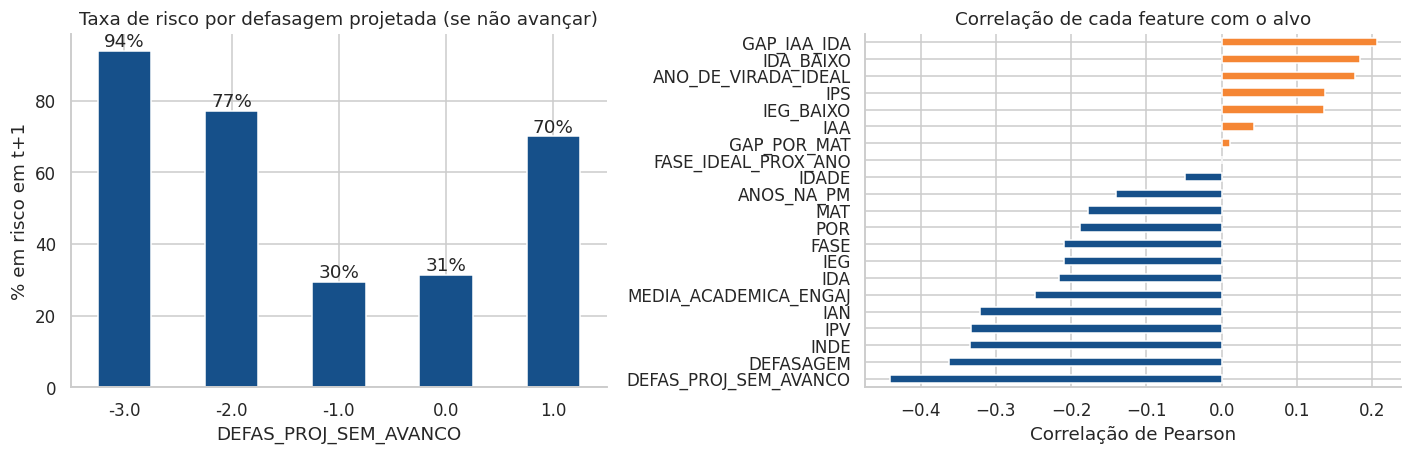

In [4]:
# Poder de separação das features criadas
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
tx = pd.crosstab(X.DEFAS_PROJ_SEM_AVANCO.clip(-3, 2), y, normalize="index")[1] * 100
tx.plot(kind="bar", color=AZUL, ax=ax[0]); ax[0].bar_label(ax[0].containers[0], fmt="%.0f%%")
ax[0].set(title="Taxa de risco por defasagem projetada (se não avançar)", xlabel="DEFAS_PROJ_SEM_AVANCO", ylabel="% em risco em t+1"); ax[0].tick_params(axis="x", rotation=0)
num_corr = X.select_dtypes("number").assign(ALVO=y).corr()["ALVO"].drop("ALVO").sort_values()
num_corr.plot(kind="barh", color=[LARANJA if v > 0 else AZUL for v in num_corr], ax=ax[1])
ax[1].set(title="Correlação de cada feature com o alvo", xlabel="Correlação de Pearson")
salvar("m1_features")

## 2. Separação treino / teste

- **Holdout 80/20 estratificado e agrupado por aluno (RA):** o mesmo aluno pode aparecer em dois pares (2022→23 e 2023→24); agrupar por RA garante que ele fique **inteiro** no treino **ou** no teste — sem vazamento.
- **Validação cruzada (5 folds, também agrupada)** dentro do treino para comparar algoritmos e escolher o limiar.
- **Validação temporal** adicional: treinar em 2022→2023 e testar em 2023→2024, simulando o uso real (prever o futuro com o passado).

In [5]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tr_idx, te_idx = next(sgkf.split(X, y, groups))
X_tr, X_te, y_tr, y_te = X.iloc[tr_idx], X.iloc[te_idx], y[tr_idx], y[te_idx]
g_tr = groups[tr_idx]
print(f"Treino: {len(X_tr)} ({y_tr.mean():.1%} risco) | Teste: {len(X_te)} ({y_te.mean():.1%} risco)")
print("Alunos em comum entre treino e teste:", len(set(groups[tr_idx]) & set(groups[te_idx])))

Treino: 1044 (53.3% risco) | Teste: 262 (53.4% risco)
Alunos em comum entre treino e teste: 0


## 3. Modelagem
Comparamos um **baseline de regra** ("já está defasado hoje → estará em risco") com três algoritmos.

In [6]:
num_cols = [c for c in FEATURES if c not in CAT_INPUT]
def preproc(scale):
    steps = [("imp", SimpleImputer(strategy="median", add_indicator=True))] + ([("sc", StandardScaler())] if scale else [])
    return ColumnTransformer([("num", Pipeline(steps), num_cols), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_INPUT)])

modelos = {
    "Regressão Logística": Pipeline([("prep", preproc(True)), ("clf", LogisticRegression(max_iter=3000, C=0.5, class_weight="balanced"))]),
    "Random Forest": Pipeline([("prep", preproc(False)), ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                                                                                       class_weight="balanced", random_state=SEED, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("prep", preproc(False)), ("clf", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300,
                                                                                                   l2_regularization=1.0, class_weight="balanced", random_state=SEED))]),
}

def metricas(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {"ROC-AUC": roc_auc_score(y_true, proba), "PR-AUC": average_precision_score(y_true, proba),
            "Acurácia": accuracy_score(y_true, pred), "Precisão": precision_score(y_true, pred),
            "Recall": recall_score(y_true, pred), "F1": f1_score(y_true, pred)}

res, oof = {}, {}
base = (X_tr.DEFASAGEM < 0).astype(int).values
res["Baseline (D<0 hoje)"] = {**metricas(y_tr, base), "ROC-AUC": np.nan, "PR-AUC": np.nan}
for nome, m in modelos.items():
    oof[nome] = cross_val_predict(m, X_tr, y_tr, cv=StratifiedGroupKFold(5, shuffle=True, random_state=SEED), groups=g_tr, method="predict_proba")[:, 1]
    res[nome] = metricas(y_tr, oof[nome])
cv_res = pd.DataFrame(res).T.round(3); display(cv_res)

,ROC-AUC,PR-AUC,Acurácia,Precisão,Recall,F1
Baseline (D<0 hoje),NaN,NaN,0.665,0.656,0.779,0.712
Regressão Logística,0.850,0.865,0.785,0.807,0.784,0.796
Random Forest,0.890,0.890,0.812,0.808,0.849,0.828
Gradient Boosting,0.889,0.887,0.810,0.821,0.824,0.822


Melhor modelo na validação cruzada: Random Forest
Limiar escolhido: 0.49


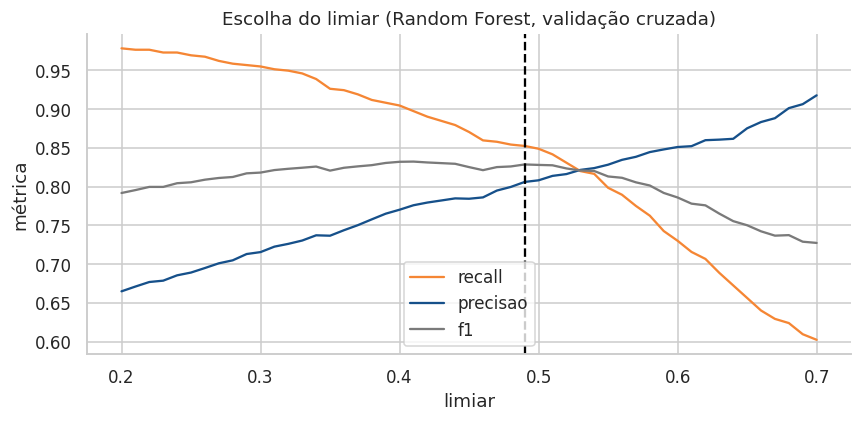

In [7]:
melhor = cv_res.drop("Baseline (D<0 hoje)")["ROC-AUC"].idxmax()
print("Melhor modelo na validação cruzada:", melhor)

# Escolha do limiar: priorizamos RECALL (não deixar aluno em risco passar despercebido),
# exigindo recall >= 0,85 e escolhendo, entre esses limiares, o de maior precisão.
thr_grid = np.arange(0.20, 0.71, 0.01)
curva = pd.DataFrame([{"limiar": t, "recall": recall_score(y_tr, oof[melhor] >= t), "precisao": precision_score(y_tr, oof[melhor] >= t),
                       "f1": f1_score(y_tr, oof[melhor] >= t)} for t in thr_grid])
LIMIAR = float(round(curva[curva.recall >= 0.85].sort_values("precisao", ascending=False).iloc[0].limiar, 2))
print("Limiar escolhido:", LIMIAR)
ax = curva.set_index("limiar")[["recall", "precisao", "f1"]].plot(color=[LARANJA, AZUL, CINZA], figsize=(8, 4))
ax.axvline(LIMIAR, ls="--", color="black"); ax.set(title=f"Escolha do limiar ({melhor}, validação cruzada)", ylabel="métrica")
salvar("m2_limiar")

## 4. Avaliação no conjunto de teste (dados nunca vistos)

,ROC-AUC,PR-AUC,Acurácia,Precisão,Recall,F1
Baseline (D<0 hoje),NaN,NaN,0.649,0.664,0.693,0.678
Random Forest (limiar 0.50),0.882,0.876,0.782,0.771,0.843,0.805
Random Forest (limiar 0.49),0.882,0.876,0.782,0.771,0.843,0.805


              precision    recall  f1-score   support

   Sem risco       0.80      0.71      0.75       122
    Em risco       0.77      0.84      0.81       140

    accuracy                           0.78       262
   macro avg       0.78      0.78      0.78       262
weighted avg       0.78      0.78      0.78       262



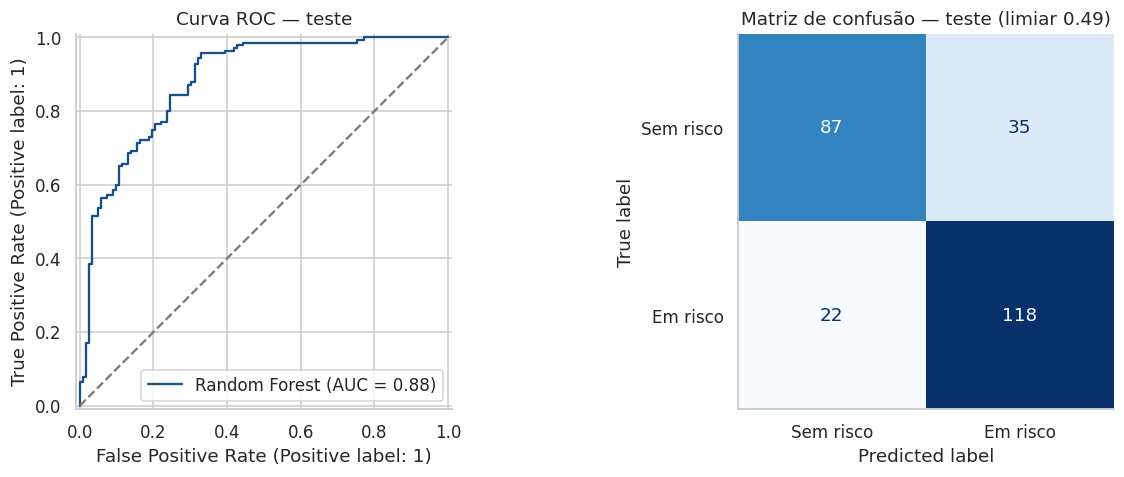

In [8]:
modelo = modelos[melhor].fit(X_tr, y_tr)
p_te = modelo.predict_proba(X_te)[:, 1]
teste = pd.DataFrame({"Baseline (D<0 hoje)": {**metricas(y_te, (X_te.DEFASAGEM < 0).astype(int).values), "ROC-AUC": np.nan, "PR-AUC": np.nan},
                      f"{melhor} (limiar 0.50)": metricas(y_te, p_te, 0.5),
                      f"{melhor} (limiar {LIMIAR:.2f})": metricas(y_te, p_te, LIMIAR)}).T.round(3)
display(teste)
print(classification_report(y_te, (p_te >= LIMIAR).astype(int), target_names=["Sem risco", "Em risco"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
RocCurveDisplay.from_predictions(y_te, p_te, ax=ax[0], color=AZUL, name=melhor); ax[0].plot([0, 1], [0, 1], "--", color=CINZA)
ax[0].set(title="Curva ROC — teste")
ConfusionMatrixDisplay.from_predictions(y_te, (p_te >= LIMIAR).astype(int), display_labels=["Sem risco", "Em risco"], cmap="Blues", ax=ax[1], colorbar=False)
ax[1].set(title=f"Matriz de confusão — teste (limiar {LIMIAR:.2f})"); ax[1].grid(False)
salvar("m3_avaliacao_teste")

In [9]:
# Calibração por faixa: a probabilidade prevista corresponde à taxa real?
faixas = pd.cut(p_te, [0, .3, .5, .7, 1.0], labels=["0-30%", "30-50%", "50-70%", "70-100%"], include_lowest=True)
cal = pd.DataFrame({"faixa": faixas, "real": y_te}).groupby("faixa").real.agg(["count", "mean"]).rename(columns={"count": "alunos", "mean": "taxa real de risco"})
display(cal.round(2))

,alunos,taxa real de risco
faixa,,
0-30%,82,0.07
30-50%,27,0.59
50-70%,67,0.58
70-100%,86,0.92


### Validação temporal (treina 2022→2023, testa 2023→2024)

In [10]:
m_tmp = modelos[melhor]
tr_t, te_t = (P.ANO == 2022).values, (P.ANO == 2023).values
m_tmp.fit(X[tr_t], y[tr_t]); p_t = m_tmp.predict_proba(X[te_t])[:, 1]
temporal = pd.DataFrame({"Baseline (D<0 hoje)": {**metricas(y[te_t], (X[te_t].DEFASAGEM < 0).astype(int).values), "ROC-AUC": np.nan, "PR-AUC": np.nan},
                         melhor: metricas(y[te_t], p_t, LIMIAR)}).T.round(3)
display(temporal)

,ROC-AUC,PR-AUC,Acurácia,Precisão,Recall,F1
Baseline (D<0 hoje),NaN,NaN,0.616,0.567,0.691,0.623
Random Forest,0.841,0.814,0.761,0.749,0.719,0.734


A validação temporal é mais difícil porque a taxa de risco caiu de 62% (2022→23) para 43% (2023→24) — o modelo foi treinado num cenário "pior" que o seguinte. Mesmo assim mantém ROC-AUC na faixa de 0,84, bem acima da regra simples. Na prática, **re-treinar o modelo a cada ciclo do PEDE** mantém a calibração em dia.

### O que o modelo aprendeu? (importância por permutação no teste)

DEFAS_PROJ_SEM_AVANCO    0.0533
DEFASAGEM                0.0187
FASE                     0.0172
IPV                      0.0124
IDADE                    0.0114
ANOS_NA_PM               0.0046
MAT                      0.0040
GAP_POR_MAT              0.0035
IAN                      0.0027
IPS                      0.0027
POR                      0.0025
INDE                     0.0021
dtype: float64

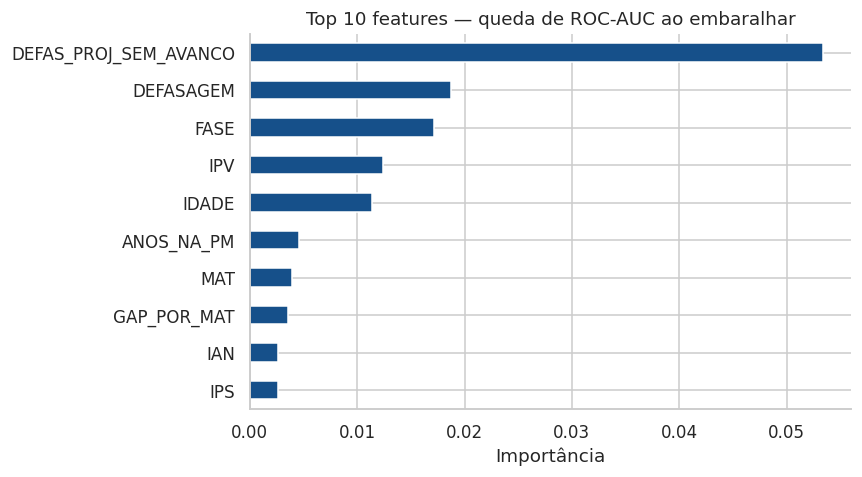

In [11]:
modelo = modelos[melhor].fit(X_tr, y_tr)
pi = permutation_importance(modelo, X_te, y_te, scoring="roc_auc", n_repeats=20, random_state=SEED)
imp = pd.Series(pi.importances_mean, index=X_te.columns).sort_values(ascending=False)
display(imp.head(12).round(4))
top = imp.head(10)[::-1]
ax = top.plot(kind="barh", color=AZUL, figsize=(8, 4.5)); ax.set(title="Top 10 features — queda de ROC-AUC ao embaralhar", xlabel="Importância")
salvar("m4_importancia")

## 5. Modelo final (treinado com todos os pares) e exportação para o app

In [12]:
final = modelos[melhor].fit(X, y)
joblib.dump(final, MODELS / "modelo_risco_defasagem.joblib")

cv_best = cv_res.loc[melhor]; te_best = teste.iloc[2]; tp_best = temporal.loc[melhor]
meta = {
    "modelo": melhor, "limiar": LIMIAR, "features": FEATURES, "num_input": NUM_INPUT, "cat_input": CAT_INPUT,
    "alvo": "RISCO_DEFASAGEM = defasado (D<0) em t+1 OU piora da defasagem entre t e t+1",
    "n_pares_treino": int(len(X)), "taxa_risco_base": float(round(y.mean(), 4)),
    "metricas_cv": {k: float(v) for k, v in cv_best.items()},
    "metricas_teste": {k: float(v) for k, v in te_best.items()},
    "metricas_temporal": {k: float(v) for k, v in tp_best.items()},
    "importancia_top": {k: float(round(v, 4)) for k, v in imp.head(10).items()},
    "versoes": {"scikit-learn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__},
    "categorias": {"GENERO": sorted(X.GENERO.unique().tolist()), "INSTITUICAO_GRUPO": sorted(X.INSTITUICAO_GRUPO.unique().tolist())},
}
(MODELS / "metadata.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2))
print(json.dumps(meta, ensure_ascii=False, indent=2)[:1500])

{
  "modelo": "Random Forest",
  "limiar": 0.49,
  "features": [
    "FASE",
    "IDADE",
    "ANOS_NA_PM",
    "DEFASAGEM",
    "INDE",
    "IAN",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPV",
    "MAT",
    "POR",
    "FASE_IDEAL_PROX_ANO",
    "DEFAS_PROJ_SEM_AVANCO",
    "ANO_DE_VIRADA_IDEAL",
    "GAP_IAA_IDA",
    "GAP_POR_MAT",
    "MEDIA_ACADEMICA_ENGAJ",
    "IEG_BAIXO",
    "IDA_BAIXO",
    "GENERO",
    "INSTITUICAO_GRUPO"
  ],
  "num_input": [
    "FASE",
    "IDADE",
    "ANOS_NA_PM",
    "DEFASAGEM",
    "INDE",
    "IAN",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPV",
    "MAT",
    "POR"
  ],
  "cat_input": [
    "GENERO",
    "INSTITUICAO_GRUPO"
  ],
  "alvo": "RISCO_DEFASAGEM = defasado (D<0) em t+1 OU piora da defasagem entre t e t+1",
  "n_pares_treino": 1306,
  "taxa_risco_base": 0.5329,
  "metricas_cv": {
    "ROC-AUC": 0.89,
    "PR-AUC": 0.89,
    "Acurácia": 0.812,
    "Precisão": 0.808,
    "Recall": 0.849,
    "F1": 0.828
  },
  "metricas_tes

In [13]:
# Exemplo de uso: ranking de risco para os alunos de 2024 (próximo ciclo = 2025)
L = pd.read_csv(ROOT / "data/processed/pede_long.csv")
a24 = L[(L.ANO == 2024) & (~L.SEM_AVALIACAO)].copy()
a24["PROB_RISCO"] = final.predict_proba(build_features(a24))[:, 1]
a24["FAIXA"] = pd.cut(a24.PROB_RISCO, [0, .3, LIMIAR, .7, 1], labels=["Baixo", "Atenção", "Alto", "Muito alto"], include_lowest=True)
print(a24.FAIXA.value_counts().reindex(["Baixo", "Atenção", "Alto", "Muito alto"]))
display(a24.sort_values("PROB_RISCO", ascending=False)[["RA", "FASE", "IDADE", "DEFASAGEM", "IDA", "IEG", "IPV", "INDE", "PROB_RISCO", "FAIXA"]].head(10).round(2))
a24[["RA", "FASE", "TURMA", "IDADE", "DEFASAGEM", "INDE", "IDA", "IEG", "PROB_RISCO", "FAIXA"]].to_csv(ROOT / "data/processed/previsao_risco_2025.csv", index=False)

FAIXA
Baixo         303
Atenção       171
Alto          246
Muito alto    335
Name: count, dtype: int64


,RA,FASE,IDADE,DEFASAGEM,IDA,IEG,IPV,INDE,PROB_RISCO,FAIXA
2344,RA-762,2.0,14.0,-2,3.75,6.42,5.75,5.97,0.97,Muito alto
2517,RA-381,3.0,15.0,-2,3.67,6.13,6.12,5.94,0.97,Muito alto
1915,RA-1299,0.0,10.0,-2,6.50,7.64,7.11,7.07,0.97,Muito alto
2187,RA-587,1.0,12.0,-2,6.25,7.38,5.74,6.82,0.97,Muito alto
2757,RA-1594,4.0,16.0,-2,3.00,6.11,6.00,5.73,0.97,Muito alto
2622,RA-1170,3.0,15.0,-2,3.50,5.57,6.75,6.10,0.96,Muito alto
2619,RA-1551,3.0,15.0,-2,3.50,4.77,6.79,5.97,0.96,Muito alto
2504,RA-558,3.0,16.0,-2,3.00,3.78,4.27,5.05,0.96,Muito alto
2563,RA-618,3.0,15.0,-2,4.17,8.32,6.83,6.72,0.96,Muito alto
2476,RA-1146,3.0,15.0,-2,2.00,5.02,5.88,5.39,0.96,Muito alto


## Conclusões da Pergunta 9

- O modelo (Random Forest) identifica alunos em risco com **ROC-AUC 0,88 no teste** (0,89 na validação cruzada) e **recall de 84%**: de cada 10 alunos que estarão defasados ou piorarão no ano seguinte, ~8 são sinalizados com antecedência. Acurácia 78% e F1 0,81.
- **Ganho claro sobre a regra** "já está defasado hoje" (acurácia 65%, F1 0,68), que ignora todos os alunos **em fase hoje** que vão atrasar (os 142 casos D = 0 → −1).
- Na validação temporal (prevendo 2024 com dados de 2022→23) a ROC-AUC fica em 0,84 — robusto, com perda natural de calibração porque a taxa de risco caiu de 62% para 46%.
- **Padrões de risco** (importância por permutação): a **defasagem projetada se o aluno não avançar de fase** (idade × fase) é de longe o sinal mais forte, seguida da **defasagem atual, fase e idade**; entre os indicadores de comportamento, pesam o **IPV**, as **notas de Matemática/Português** e o **IPS**. Tradução: aluno perto do limite de idade da fase + ponto de virada e notas baixas = risco alto.
- As probabilidades são bem ordenadas: no teste, a faixa 0–30% teve **7%** de risco real e a faixa 70–100% teve **92%**.
- **Uso recomendado:** rodar o modelo no fechamento de cada PEDE, priorizar a lista "Alto/Muito alto" para reforço acadêmico e avaliação de avanço de fase, e re-treinar anualmente.
- O modelo está disponível no app Streamlit (`streamlit_app.py`) para uso individual ou em lote (upload de planilha).